## Image Classification using CNN on CIFAR-10

## Introduction
Convolutional Neural Networks (CNNs) are powerful deep learning models used for image classification tasks. This project implements a CNN model to classify images from the CIFAR-10 dataset.

## Objectives
- Preprocess and normalize image data
- Build CNN model
- Train model
- Evaluate performance
- Analyze results

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras import datasets, layers, models
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.layers import BatchNormalization, Dropout
from tensorflow.keras.preprocessing.image import ImageDataGenerator

from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

C:\Users\Cpu\anaconda3\Lib\site-packages\keras\src\export\tf2onnx_lib.py:8: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"):


## Dataset Description

CIFAR-10 dataset contains:
- 60,000 images
- 10 classes
- 32x32 RGB images

In [2]:
(x_train, y_train), (x_test, y_test) = datasets.cifar10.load_data()

print("Train Shape:", x_train.shape)
print("Test Shape:", x_test.shape)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 29s 0us/step 
Train Shape: (50000, 32, 32, 3)
Test Shape: (10000, 32, 32, 3)


## Dataset Analysis

In [3]:
print("Training Samples:", len(x_train))
print("Testing Samples:", len(x_test))

print("Height:", x_train.shape[1])
print("Width:", x_train.shape[2])
print("Channels:", x_train.shape[3])

print("Data Type:", x_train.dtype)

Training Samples: 50000
Testing Samples: 10000
Height: 32
Width: 32
Channels: 3
Data Type: uint8


## Statistical Analysis

In [4]:
print("Mean:", np.mean(x_train))
print("Std:", np.std(x_train))
print("Min:", np.min(x_train))
print("Max:", np.max(x_train))

Mean: 120.70756512369792
Std: 64.1500758911213
Min: 0
Max: 255


## Class Distribution

Classes: [0 1 2 3 4 5 6 7 8 9]
6    5000
9    5000
4    5000
1    5000
2    5000
7    5000
8    5000
3    5000
5    5000
0    5000
Name: count, dtype: int64


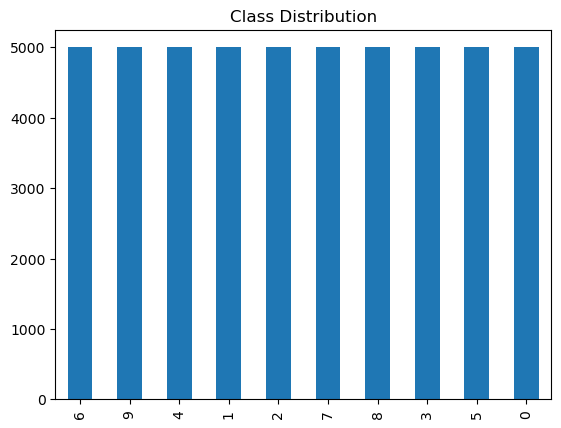

In [5]:
unique = np.unique(y_train)
print("Classes:", unique)

counts = pd.Series(y_train.flatten()).value_counts()
print(counts)

counts.plot(kind='bar')
plt.title("Class Distribution")
plt.show()

## Visualization

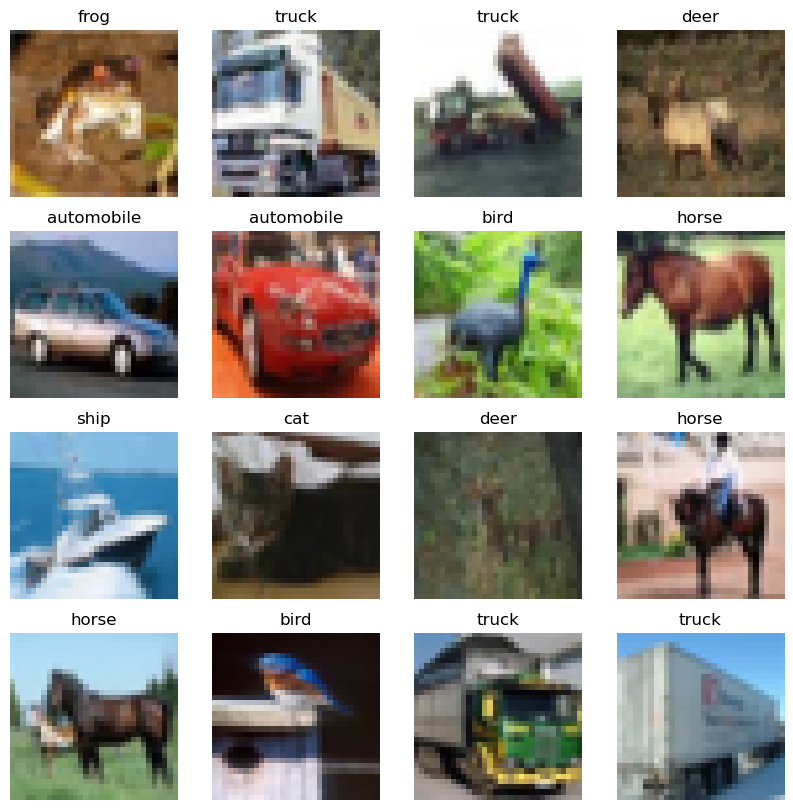

In [6]:
class_names = ['airplane','automobile','bird','cat','deer',
               'dog','frog','horse','ship','truck']

plt.figure(figsize=(10,10))
for i in range(16):
    plt.subplot(4,4,i+1)
    plt.imshow(x_train[i])
    plt.title(class_names[y_train[i][0]])
    plt.axis('off')
plt.show()

## Data Quality Check

In [8]:
df = pd.DataFrame(x_train.reshape(len(x_train), -1))

print("Duplicates:", df.duplicated().sum())
print("Missing:", df.isnull().sum().sum())

Duplicates: 0
Missing: 0


## Pixel Distribution

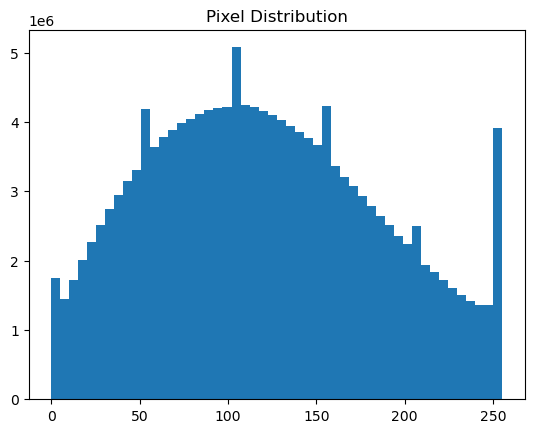

In [9]:
plt.hist(x_train.flatten(), bins=50)
plt.title("Pixel Distribution")
plt.show()

## Data Preprocessing

In [25]:
x_train = x_train / 255.0
x_test = x_test / 255.0

y_train_cat = to_categorical(y_train, 10)
y_test_cat = to_categorical(y_test, 10)

## Data Augmentation

In [24]:
datagen = ImageDataGenerator(
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True
)

datagen.fit(x_train)

## CNN Model Building

In [16]:
model = models.Sequential()

model.add(layers.Conv2D(32,(3,3),activation='relu',input_shape=(32,32,3)))
model.add(BatchNormalization())
model.add(layers.MaxPooling2D((2,2)))

model.add(layers.Conv2D(64,(3,3),activation='relu'))
model.add(BatchNormalization())
model.add(layers.MaxPooling2D((2,2)))

model.add(layers.Conv2D(128,(3,3),activation='relu'))
model.add(BatchNormalization())

model.add(layers.Flatten())

model.add(layers.Dense(128,activation='relu'))
model.add(Dropout(0.5))

model.add(layers.Dense(10,activation='softmax'))

C:\Users\Cpu\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


## Model Compilation

In [17]:
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 30, 30, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 13, 13, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 4, 4, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 4, 4, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 357,706 (1.36 MB)

 Trainable params: 357,258 (1.36 MB)

 Non-trainable params: 448 (1.75 KB)

## Model Training

In [18]:
history = model.fit(
    x_train, y_train_cat,
    epochs=15,
    validation_data=(x_test, y_test_cat)
)

Epoch 1/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 17s 9ms/step - accuracy: 0.1254 - loss: 2.2651 - val_accuracy: 0.1000 - val_loss: 58528.5586
Epoch 2/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 15s 9ms/step - accuracy: 0.2214 - loss: 2.1131 - val_accuracy: 0.1000 - val_loss: 778229.3750
Epoch 3/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 21s 10ms/step - accuracy: 0.2460 - loss: 2.0718 - val_accuracy: 0.1000 - val_loss: 48882.8867
Epoch 4/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 15s 10ms/step - accuracy: 0.2246 - loss: 2.1050 - val_accuracy: 0.1000 - val_loss: 5408797.0000
Epoch 5/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 15s 10ms/step - accuracy: 0.2624 - loss: 2.0308 - val_accuracy: 0.1000 - val_loss: 3292595.0000
Epoch 6/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 15s 10ms/step - accuracy: 0.2822 - loss: 1.9889 - val_accuracy: 0.1000 - val_loss: 697887.7500
Epoch 7/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 21s 10ms/step - accuracy: 0.2880 - loss: 1.9796 - val_accuracy: 0.1000 - val_loss: 3135090.5000
Epoch 8/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 

## Evaluation

In [23]:
loss, acc = model.evaluate(x_test, y_test_cat)
print("Accuracy:", acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.1000 - loss: 16.6165 
Accuracy: 0.10000000149011612


## Accuracy Graph

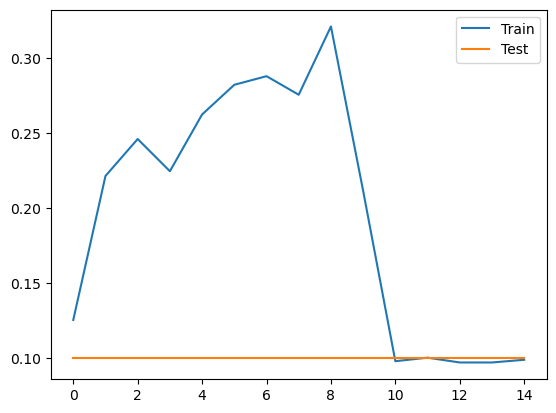

In [22]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.legend(['Train','Test'])
plt.show()

## Loss Graph

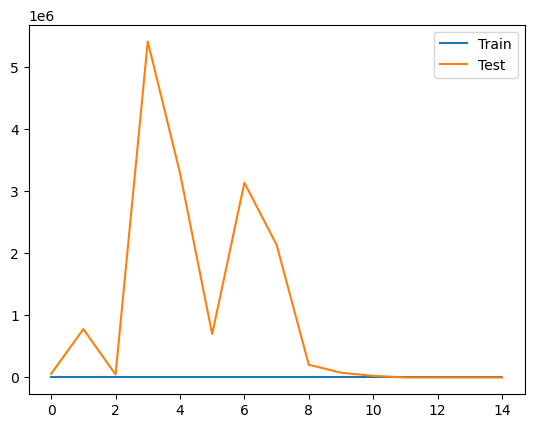

In [26]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.legend(['Train','Test'])
plt.show()

## Confusion Matrix

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step  


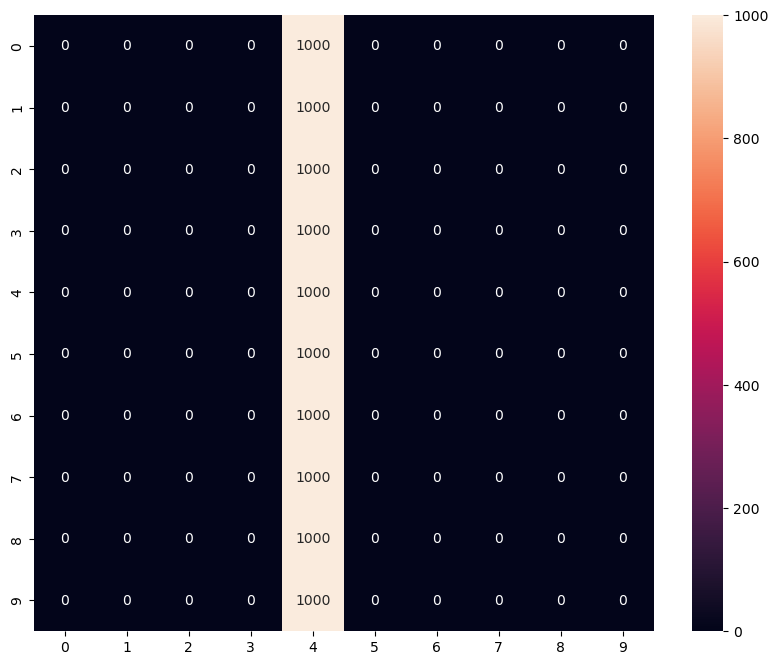

In [27]:
y_pred = model.predict(x_test)
y_pred_classes = np.argmax(y_pred, axis=1)

cm = confusion_matrix(y_test, y_pred_classes)

plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt='d')
plt.show()